In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers

In [ ]:
mnist = keras.datasets.mnist
(x_train, y_train) , (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train/255.0 , x_test/255.0

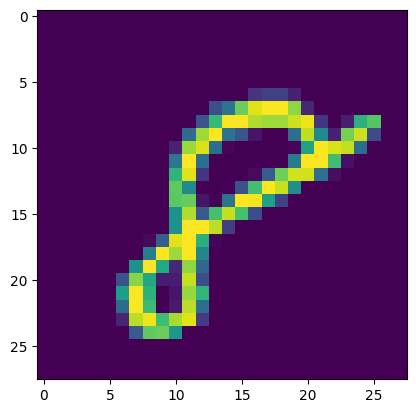

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[59999])

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
model = keras.Sequential(
    [
        layers.Flatten(input_shape=(28,28,1)),
        layers.Dense(128,activation='relu'),
        layers.Dense(10,activation='softmax')
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer= 'adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train, validation_split=0.1, epochs=20)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9223 - loss: 0.2731 - val_accuracy: 0.9660 - val_loss: 0.1224
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9652 - loss: 0.1176 - val_accuracy: 0.9713 - val_loss: 0.0980
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9757 - loss: 0.0805 - val_accuracy: 0.9748 - val_loss: 0.0856
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9816 - loss: 0.0604 - val_accuracy: 0.9757 - val_loss: 0.0841
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9854 - loss: 0.0464 - val_accuracy: 0.9788 - val_loss: 0.0797
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9889 - loss: 0.0360 - val_accuracy: 0.9785 - val_loss: 0.0862
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9906 - loss: 0.0292 - val_accuracy: 0.9797 - val_loss: 0.0851
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9933 - loss: 0.0240 

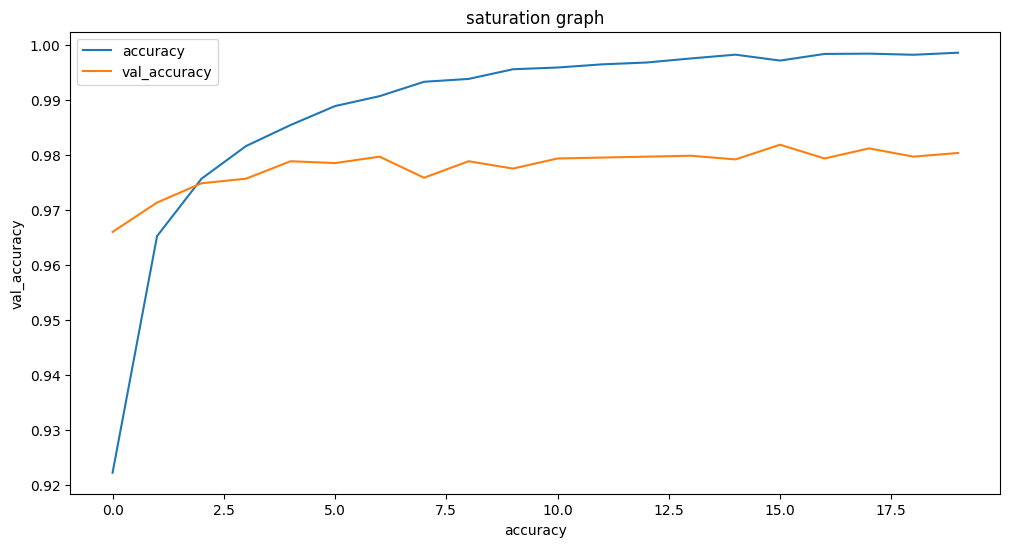

In [ ]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.lineplot(history.history["accuracy"], label='accuracy')
sns.lineplot(history.history["val_accuracy"], label="val_accuracy")
plt.title("saturation graph")
plt.xlabel("accuracy")
plt.ylabel("val_accuracy")
plt.show()

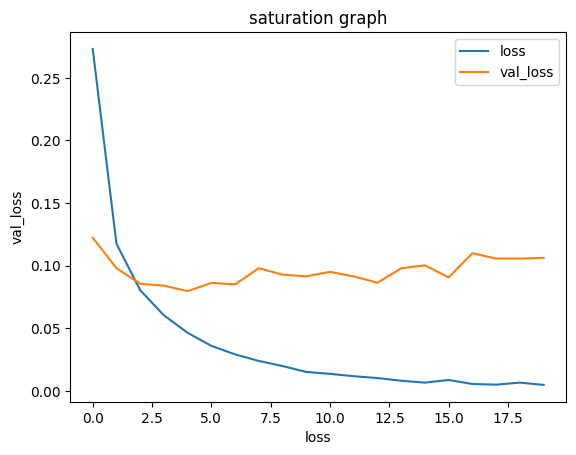

In [ ]:
sns.lineplot(history.history["loss"], label='loss')
sns.lineplot(history.history["val_loss"], label="val_loss")
plt.title("saturation graph")
plt.xlabel("loss")
plt.ylabel("val_loss")
plt.show()

In [ ]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
y_pred.shape

(10000, 10)

In [ ]:
y_pred[0]

array([1.0356850e-18, 2.2285899e-14, 7.5029051e-13, 4.5157825e-10,
       5.7975004e-23, 7.2215197e-16, 3.7440597e-24, 9.9999994e-01,
       3.9448245e-14, 5.8844246e-10], dtype=float32)

In [ ]:
import numpy as np
y_pred1 = np.argmax(y_pred, axis=1)


In [ ]:
y_pred1[2]

np.int64(1)

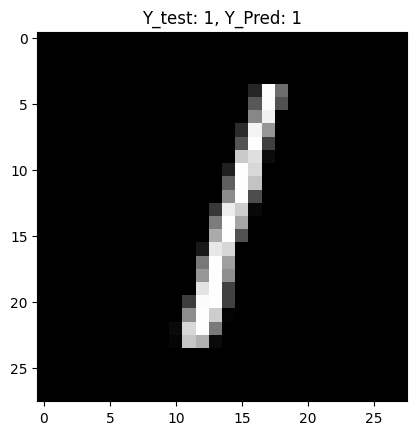

In [ ]:
plt.imshow(x_test[2].reshape(28,28), cmap='gray')
plt.title(f"Y_test: {y_test[2]}, Y_Pred: {y_pred1[2]}")
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("/content/sample7_pic_for_dl.png", cv2.IMREAD_GRAYSCALE)


In [ ]:
from google.colab.patches import cv2_imshow

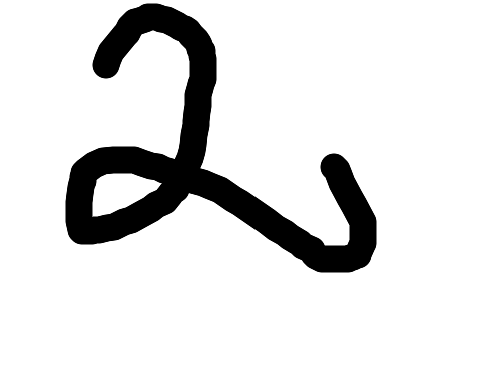

In [ ]:
cv2_imshow(img)

In [ ]:
img.shape

(374, 496)

In [ ]:
img = 255 - img
img1 = img / 255.0

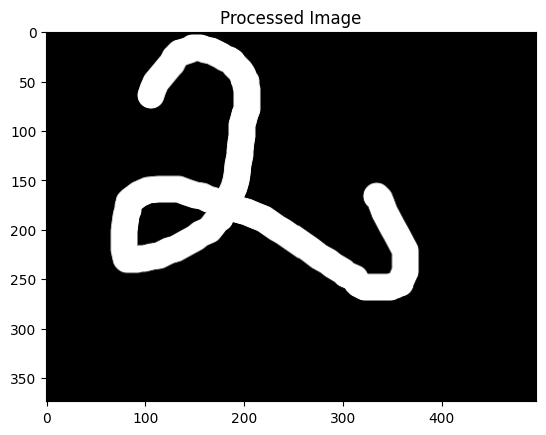

In [ ]:
plt.imshow(img1, cmap='gray')
plt.title("Processed Image")
plt.show()

In [ ]:

img1 = cv2.resize(img,(28,28))
img2 = img1 / 255.0

In [ ]:
img3 = img2.reshape(1, 28, 28)

In [ ]:
y_pred = model.predict(img3)

digit = np.argmax(y_pred)

print("Predicted Digit:", digit)
print("Confidence:", np.max(y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Digit: 6
Confidence: 1.0


In [ ]:
model.save('minst_model.h5')